In [24]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [25]:
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target)

In [26]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [27]:
clf = LogisticRegression(max_iter=5000,random_state=42)
clf.fit(X_train_s,y_train)


LogisticRegression(max_iter=5000, random_state=42)

In [28]:
y_pred = clf.predict(X_test_s)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1       : 0.9861


First 5 predicted probabilities [P(malignant), P(benign)]:
[[1.    0.   ]
 [0.    1.   ]
 [0.994 0.006]
 [0.466 0.534]
 [1.    0.   ]]

P(class1) for first 5: [0.    1.    0.006 0.534 0.   ]
predicted labels      : [0 1 0 1 0]
clf.predict matches?  : True

threshold  precision  recall
   0.3      0.973     1.000
   0.5      0.986     0.986
   0.7      0.985     0.931
   0.9      0.984     0.847


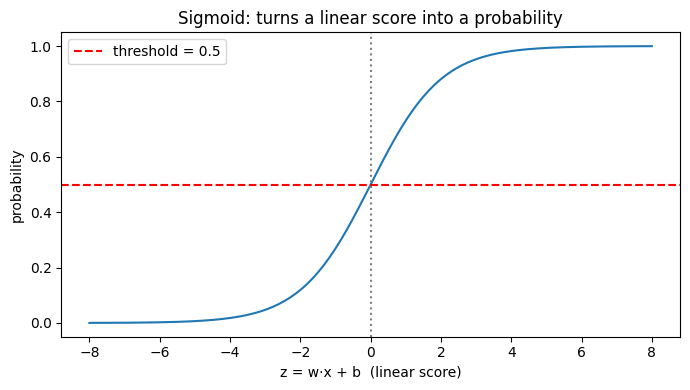

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))          # squashes any real number into (0,1)

# --- 2. predict_proba gives the probability of each class ---
proba = clf.predict_proba(X_test_s)      # shape (n,2): [P(class0), P(class1)]
print("First 5 predicted probabilities [P(malignant), P(benign)]:")
print(np.round(proba[:5], 3))

# --- 3. predict() is just predict_proba thresholded at 0.5 ---
p1 = proba[:, 1]                          # probability of class 1 (benign)
print("\nP(class1) for first 5:", np.round(p1[:5], 3))
print("predicted labels      :", (p1[:5] >= 0.5).astype(int))
print("clf.predict matches?  :", np.array_equal((p1 >= 0.5).astype(int), clf.predict(X_test_s)))

# --- 4. Sweep the threshold: precision vs recall trade-off ---
print("\nthreshold  precision  recall")
for t in [0.3, 0.5, 0.7, 0.9]:
    pred_t = (p1 >= t).astype(int)
    print(f"  {t:>4}      {precision_score(y_test, pred_t):.3f}     {recall_score(y_test, pred_t):.3f}")

# --- 5. Plot the sigmoid ---
z = np.linspace(-8, 8, 200)
plt.figure(figsize=(7,4))
plt.plot(z, sigmoid(z))
plt.axhline(0.5, color='red', ls='--', label='threshold = 0.5')
plt.axvline(0, color='gray', ls=':')
plt.xlabel('z = w·x + b  (linear score)'); plt.ylabel('probability')
plt.title('Sigmoid: turns a linear score into a probability')
plt.legend(); plt.tight_layout(); plt.savefig('sigmoid.png', dpi=110); plt.show()

**Regularization L1 and L2**

In [30]:
print("L2 penalty:")
print(f"{'C':>8}{'test_acc':>10}{'sum|coef|':>12}")
for C in [0.001,0.01,0.1,1,10,100]:
    m = LogisticRegression(max_iter=5000,C=C, penalty='l2',random_state=42).fit(X_train_s,y_train)
    acc = accuracy_score(y_test, m.predict(X_test_s))
    print(f"{C:>8}{acc:>10.4f}{np.abs(m.coef_).sum():>12.2f}")  

L2 penalty:
       C  test_acc   sum|coef|
   0.001    0.9298        1.44
    0.01    0.9474        4.03
     0.1    0.9737        8.83
       1    0.9825       17.25
      10    0.9649       33.95
     100    0.9474       94.24


**L1 VS L2**

In [31]:
print("\nL1 vs L2 at C=0.1 (30 features total):")
for pen in ['l1', 'l2']:
    m = LogisticRegression(C=1, penalty=pen, solver='liblinear',  # liblinear supports L1
                           max_iter=5000, random_state=42).fit(X_train_s, y_train)
    n_zero = int((m.coef_[0] == 0).sum())
    acc = accuracy_score(y_test, m.predict(X_test_s))
    print(f"  {pen}: test_acc={acc:.4f}  features set to ZERO = {n_zero}/30")


L1 vs L2 at C=0.1 (30 features total):
  l1: test_acc=0.9912  features set to ZERO = 14/30
  l2: test_acc=0.9825  features set to ZERO = 0/30


**Meow**